# Project: Wrangling and Analyze Data

## Data Gathering
In the cell below, gather **all** three pieces of data for this project and load them in the notebook. **Note:** the methods required to gather each data are different.
1. Directly download the WeRateDogs Twitter archive data (twitter_archive_enhanced.csv)

In [61]:
# Importing necessary libraries for data manipulation (pandas), numerical operations (numpy), and visualization (matplotlib)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [62]:
# Reading the WeRateDogs Twitter archive CSV file into a pandas DataFrame
twitter_archive = pd.read_csv("twitter-archive-enhanced.csv")

# Displaying the first 3 rows of the DataFrame to get an initial look at the data
twitter_archive.head(3)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,NaN,NaN,NaN,NaN
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,NaN,NaN,NaN,NaN
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,NaN,NaN,NaN,NaN


2. Use the Requests library to download the tweet image prediction (image_predictions.tsv)

In [63]:
# Importing the requests library to handle HTTP requests
import requests

# URL of the image predictions data file
url = 'https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv'

# Sending a GET request to the URL to fetch the image predictions data
response = requests.get(url)

# Saving the content of the response to a local file named 'image-predictions.tsv'
with open('image-predictions.tsv', mode='wb') as file:
    file.write(response.content)

# Reading the saved TSV file into a pandas DataFrame
image_predictions = pd.read_csv('image-predictions.tsv', sep='\t')

# Displaying the first 3 rows of the DataFrame to get an initial look at the data
image_predictions.head(3)

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True


3. Use the Tweepy library to query additional data via the Twitter API (tweet_json.txt)




In [64]:
# Importing the tweepy library for accessing the Twitter API and the json library for handling JSON data
import tweepy
import json

# Initializing an empty list to store tweet data
tweets_data = []

# Opening the JSON file containing tweet data
with open('tweet_json.txt', 'r') as file:
    # Reading each line (tweet) in the file
    for line in file:
        # Parsing the JSON data from the line
        tweet = json.loads(line)
        # Extracting the tweet ID, retweet count, and favorite count
        tweet_id = tweet['id']
        retweet_count = tweet['retweet_count']
        favorite_count = tweet['favorite_count']
        # Appending the extracted data as a dictionary to the tweets_data list
        tweets_data.append({'tweet_id': tweet_id, 'retweet_count': retweet_count, 'favorite_count': favorite_count})

# Creating a pandas DataFrame from the list of tweet data
tweet_df = pd.DataFrame(tweets_data)

# Displaying the first few rows of the DataFrame to get an initial look at the data
tweet_df.head()

,tweet_id,retweet_count,favorite_count
0,892420643555336193,8853,39467
1,892177421306343426,6514,33819
2,891815181378084864,4328,25461
3,891689557279858688,8964,42908
4,891327558926688256,9774,41048


## Assessing Data
In this section, detect and document at least **eight (8) quality issues and two (2) tidiness issue**. You must use **both** visual assessment
programmatic assessement to assess the data.

**Note:** pay attention to the following key points when you access the data.

* You only want original ratings (no retweets) that have images. Though there are 5000+ tweets in the dataset, not all are dog ratings and some are retweets.
* Assessing and cleaning the entire dataset completely would require a lot of time, and is not necessary to practice and demonstrate your skills in data wrangling. Therefore, the requirements of this project are only to assess and clean at least 8 quality issues and at least 2 tidiness issues in this dataset.
* The fact that the rating numerators are greater than the denominators does not need to be cleaned. This [unique rating system](http://knowyourmeme.com/memes/theyre-good-dogs-brent) is a big part of the popularity of WeRateDogs.
* You do not need to gather the tweets beyond August 1st, 2017. You can, but note that you won't be able to gather the image predictions for these tweets since you don't have access to the algorithm used.



In [65]:
# Displaying a summary of the twitter_archive DataFrame, including the column names, non-null counts, and data types
twitter_archive.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   object 
 4   source                      2356 non-null   object 
 5   text                        2356 non-null   object 
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    object 
 9   expanded_urls               2297 non-null   object 
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        1611 non-null   object 
 13  doggo                       97 no

In [66]:
# Displaying a summary of the image_predictions DataFrame, including column names, non-null counts, and data types
image_predictions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  2075 non-null   int64  
 1   jpg_url   2075 non-null   object 
 2   img_num   2075 non-null   int64  
 3   p1        2075 non-null   object 
 4   p1_conf   2075 non-null   float64
 5   p1_dog    2075 non-null   bool   
 6   p2        2075 non-null   object 
 7   p2_conf   2075 non-null   float64
 8   p2_dog    2075 non-null   bool   
 9   p3        2075 non-null   object 
 10  p3_conf   2075 non-null   float64
 11  p3_dog    2075 non-null   bool   
dtypes: bool(3), float64(3), int64(2), object(4)
memory usage: 152.1+ KB


In [67]:
# Displaying a summary of the tweet_df DataFrame, including column names, non-null counts, and data types
tweet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   tweet_id        2354 non-null   int64
 1   retweet_count   2354 non-null   int64
 2   favorite_count  2354 non-null   int64
dtypes: int64(3)
memory usage: 55.3 KB


### **Quality issues**
####**Concerning the twitter archive dataset:**

*   As the only needed id is the tweet id, so the columns 3,4,8,9 and 10 should be removed.
*   The timestamp column must be classified into date data type instead of object data type.
*   The "+0000" thing must be removed from the values in timestamp column.

*   The HTML tag must be removed from the source column values.
*   The numerator and denominator ratings must be converted into object datatype instead of integer datatype.

####**Image preditions dataset"**

*   tweet_id columns must be converted into object datatype instead of the integer datatype.
*   Capitalization is not consistent in p1,p2 and p3 columns.

####**Tweet JSON dataset"**

*   tweet_id columns must be converted into object datatype instead of integer datatype.



### **Tidiness issues**
  1.The rating numerator and rating denominator must be merged in one column in the twitter archive dataset.

  2.The last four columns of dogs breeds must be merged.

## Cleaning Data
In this section, clean **all** of the issues you documented while assessing.

**Note:** Make a copy of the original data before cleaning. Cleaning includes merging individual pieces of data according to the rules of [tidy data](https://cran.r-project.org/web/packages/tidyr/vignettes/tidy-data.html). The result should be a high-quality and tidy master pandas DataFrame (or DataFrames, if appropriate).

In [68]:
# Make copies of original pieces of data
twitter_archive_clean = twitter_archive.copy()
image_predictions_clean = image_predictions.copy()
tweet_df_clean = tweet_df.copy()

## Cleaning Quality Issues

### **Twitter_archive dataset cleaning**

### Issue #1:Uneccesry columns.

#### Define: As the only needed id is the tweet id, so the columns 3,4,8,9 and 10 should be removed.

#### Code

In [69]:
# Dropping columns from the twitter_archive DataFrame that are not needed for analysis
twitter_archive = twitter_archive.drop(columns=['in_reply_to_status_id', 'in_reply_to_user_id',
                                                'retweeted_status_id', 'retweeted_status_timestamp',
                                                'retweeted_status_user_id'])

#### Test

In [10]:
# Displaying the first row of the twitter_archive DataFrame to get a snapshot of the data after column removal
twitter_archive.head(1)

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,NaN,NaN,NaN,NaN


### Issue #2: Wrong datatype

#### Define: The timestamp column must be classified into date data type instead of object data type.


#### Code

In [70]:
# Converting the 'timestamp' column in the twitter_archive DataFrame from string format to datetime format
twitter_archive['timestamp'] = pd.to_datetime(twitter_archive['timestamp'])

#### Test

In [71]:
# Displaying a summary of the twitter_archive DataFrame to confirm the changes, including data types and non-null counts
twitter_archive.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   tweet_id            2356 non-null   int64              
 1   timestamp           2356 non-null   datetime64[ns, UTC]
 2   source              2356 non-null   object             
 3   text                2356 non-null   object             
 4   expanded_urls       2297 non-null   object             
 5   rating_numerator    2356 non-null   int64              
 6   rating_denominator  2356 non-null   int64              
 7   name                1611 non-null   object             
 8   doggo               97 non-null     object             
 9   floofer             10 non-null     object             
 10  pupper              257 non-null    object             
 11  puppo               30 non-null     object             
dtypes: datetime64[ns, UTC](1), int64(3

### Issue #3: Useless repetitive value

#### Define: The "+0000" thing must be removed from the values in timestamp column.


#### Code

In [72]:
# Converting the 'timestamp' column in the twitter_archive DataFrame from datetime format to string format
twitter_archive['timestamp'] = twitter_archive['timestamp'].astype(str)

# Removing the '+00:00' timezone information from the 'timestamp' column by replacing it with an empty string
twitter_archive['timestamp'] = twitter_archive['timestamp'].str.replace('+00:00', '', regex=False)

#### Test

In [73]:
# Displaying the first 4 rows of the twitter_archive DataFrame to examine the changes made to the 'timestamp' column
twitter_archive.head(4)

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,2017-08-01 16:23:56,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,NaN,NaN,NaN,NaN
1,892177421306343426,2017-08-01 00:17:27,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,NaN,NaN,NaN,NaN
2,891815181378084864,2017-07-31 00:18:03,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,NaN,NaN,NaN,NaN
3,891689557279858688,2017-07-30 15:58:51,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,NaN,NaN,NaN,NaN


### Issue #4: Useless HTML tag

#### Define: The HTML tag must be removed from the source column values.



#### Code

In [74]:
# Extracting the source URL from the 'source' column using a regular expression and removing HTML tags
twitter_archive['source'] = twitter_archive['source'].str.extract(r'<a href="(.+)">.+</a>', expand=False)

# Removing any remaining double quotes from the 'source' column
twitter_archive['source'] = twitter_archive['source'].str.replace('"', '')

#### Test

In [75]:
# Displaying the first few rows of the twitter_archive DataFrame to review the changes made to the 'source' column
twitter_archive.head()

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,2017-08-01 16:23:56,http://twitter.com/download/iphone rel=nofollow,This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,NaN,NaN,NaN,NaN
1,892177421306343426,2017-08-01 00:17:27,http://twitter.com/download/iphone rel=nofollow,This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,NaN,NaN,NaN,NaN
2,891815181378084864,2017-07-31 00:18:03,http://twitter.com/download/iphone rel=nofollow,This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,NaN,NaN,NaN,NaN
3,891689557279858688,2017-07-30 15:58:51,http://twitter.com/download/iphone rel=nofollow,This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,NaN,NaN,NaN,NaN
4,891327558926688256,2017-07-29 16:00:24,http://twitter.com/download/iphone rel=nofollow,This is Franklin. He would like you to stop ca...,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,NaN,NaN,NaN,NaN


### Issue #5: The numertor and denominator ratings are integer datatype.

#### Define: The numerator and denominator ratings must be converted into object datatype instead of integer datatype.



#### Code

In [76]:
# Converting the 'rating_numerator' column to string type
twitter_archive['rating_numerator'] = twitter_archive['rating_numerator'].astype(str)

# Converting the 'rating_denominator' column to string type
twitter_archive['rating_denominator'] = twitter_archive['rating_denominator'].astype(str)

#### Test

In [77]:
# Displaying a summary of the twitter_archive DataFrame to confirm the data type changes for 'rating_numerator' and 'rating_denominator'
twitter_archive.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_id            2356 non-null   int64 
 1   timestamp           2356 non-null   object
 2   source              2356 non-null   object
 3   text                2356 non-null   object
 4   expanded_urls       2297 non-null   object
 5   rating_numerator    2356 non-null   object
 6   rating_denominator  2356 non-null   object
 7   name                1611 non-null   object
 8   doggo               97 non-null     object
 9   floofer             10 non-null     object
 10  pupper              257 non-null    object
 11  puppo               30 non-null     object
dtypes: int64(1), object(11)
memory usage: 221.0+ KB


### **Image_predections dataset cleaning**

### Issue #6: Wrong datatype for the tweet_id column

#### Define: tweet_id columns must be converted into object datatype instead of the integer datatype.


#### Code

In [78]:
# Converting the 'tweet_id' column in the image_predictions DataFrame to string type
image_predictions['tweet_id'] = image_predictions['tweet_id'].astype(str)

#### Test

In [79]:
# Displaying a summary of the image_predictions DataFrame to confirm the data type change for 'tweet_id'
image_predictions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  2075 non-null   object 
 1   jpg_url   2075 non-null   object 
 2   img_num   2075 non-null   int64  
 3   p1        2075 non-null   object 
 4   p1_conf   2075 non-null   float64
 5   p1_dog    2075 non-null   bool   
 6   p2        2075 non-null   object 
 7   p2_conf   2075 non-null   float64
 8   p2_dog    2075 non-null   bool   
 9   p3        2075 non-null   object 
 10  p3_conf   2075 non-null   float64
 11  p3_dog    2075 non-null   bool   
dtypes: bool(3), float64(3), int64(1), object(5)
memory usage: 152.1+ KB


### Issue #7: Wronge Capitalization in p1, p2 and p3.

#### Define: Capitalization is not consistent in p1,p2 and p3 columns, some are small and some are captial.



#### Code

In [80]:
# Capitalizing the first letter of each string in the 'p1' column
image_predictions['p1'] = image_predictions['p1'].str.capitalize()

# Capitalizing the first letter of each string in the 'p2' column
image_predictions['p2'] = image_predictions['p2'].str.capitalize()

# Capitalizing the first letter of each string in the 'p3' column
image_predictions['p3'] = image_predictions['p3'].str.capitalize()

#### Test

In [81]:
# Displaying the first few rows of the image_predictions DataFrame to review the changes made to the 'p1', 'p2', and 'p3' columns
image_predictions.head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,Collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,Redbone,0.506826,True,Miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,Malinois,0.138584,True,Bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,Redbone,0.360687,True,Miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,Miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


### **Tweet JSON dataset cleaning**

### Issue #8: Wrong integer datatype in tweet_id column

#### Define: tweet_id columns must be converted into object datatype instead of integer datatype.


#### Code

In [82]:
# Converting the 'tweet_id' column in the tweet_df DataFrame to string type
tweet_df["tweet_id"] = tweet_df["tweet_id"].astype(str)

#### Test

In [83]:
# Displaying a summary of the tweet_df DataFrame to confirm the data type change for 'tweet_id'
tweet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   tweet_id        2354 non-null   object
 1   retweet_count   2354 non-null   int64 
 2   favorite_count  2354 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 55.3+ KB


## Cleaning Tidiness Issues

### Issue #1: Two columns for ratings

#### Define: The rating numerator and rating denominator must be merged in one column in the twitter archive dataset.


#### Code

In [84]:
# Creating a new column 'rating' in the twitter_archive DataFrame by concatenating 'rating_numerator' and 'rating_denominator' with a '/' separator
twitter_archive['rating'] = twitter_archive['rating_numerator'] + '/' + twitter_archive['rating_denominator']

# Dropping the 'rating_numerator' and 'rating_denominator' columns from the twitter_archive DataFrame as they are no longer needed
twitter_archive = twitter_archive.drop(columns=['rating_numerator', 'rating_denominator'])

#### Test

In [85]:
# Displaying the first few rows of the twitter_archive DataFrame to review the new 'rating' column and confirm the removal of 'rating_numerator' and 'rating_denominator'
twitter_archive.head()

,tweet_id,timestamp,source,text,expanded_urls,name,doggo,floofer,pupper,puppo,rating
0,892420643555336193,2017-08-01 16:23:56,http://twitter.com/download/iphone rel=nofollow,This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,Phineas,NaN,NaN,NaN,NaN,13/10
1,892177421306343426,2017-08-01 00:17:27,http://twitter.com/download/iphone rel=nofollow,This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,Tilly,NaN,NaN,NaN,NaN,13/10
2,891815181378084864,2017-07-31 00:18:03,http://twitter.com/download/iphone rel=nofollow,This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,Archie,NaN,NaN,NaN,NaN,12/10
3,891689557279858688,2017-07-30 15:58:51,http://twitter.com/download/iphone rel=nofollow,This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,Darla,NaN,NaN,NaN,NaN,13/10
4,891327558926688256,2017-07-29 16:00:24,http://twitter.com/download/iphone rel=nofollow,This is Franklin. He would like you to stop ca...,https://twitter.com/dog_rates/status/891327558...,Franklin,NaN,NaN,NaN,NaN,12/10


### Issue #2: The last four columns are full with nan values.

#### Define: The last four columns of dogs breeds must be merged.

#### Code

In [86]:
# Combining the 'doggo', 'floofer', 'pupper', and 'puppo' columns into a new column 'dog_breed'
# The .combine_first() method is used to fill missing values from the first column with non-missing values from the next columns
twitter_archive['dog_breed'] = twitter_archive['doggo']\
                                  .combine_first(twitter_archive['floofer'])\
                                  .combine_first(twitter_archive['pupper'])\
                                  .combine_first(twitter_archive['puppo'])

# Dropping the original 'doggo', 'floofer', 'pupper', and 'puppo' columns from the twitter_archive DataFrame as they are no longer needed
twitter_archive = twitter_archive.drop(columns=['doggo', 'floofer', 'pupper', 'puppo'])

#### Test

In [87]:
# Displaying the first few rows of the twitter_archive DataFrame to review the new 'dog_breed' column and confirm the removal of 'doggo', 'floofer', 'pupper', and 'puppo'
twitter_archive.head()

,tweet_id,timestamp,source,text,expanded_urls,name,rating,dog_breed
0,892420643555336193,2017-08-01 16:23:56,http://twitter.com/download/iphone rel=nofollow,This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,Phineas,13/10,NaN
1,892177421306343426,2017-08-01 00:17:27,http://twitter.com/download/iphone rel=nofollow,This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,Tilly,13/10,NaN
2,891815181378084864,2017-07-31 00:18:03,http://twitter.com/download/iphone rel=nofollow,This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,Archie,12/10,NaN
3,891689557279858688,2017-07-30 15:58:51,http://twitter.com/download/iphone rel=nofollow,This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,Darla,13/10,NaN
4,891327558926688256,2017-07-29 16:00:24,http://twitter.com/download/iphone rel=nofollow,This is Franklin. He would like you to stop ca...,https://twitter.com/dog_rates/status/891327558...,Franklin,12/10,NaN


## Storing Data
Save gathered, assessed, and cleaned master dataset to a CSV file named "twitter_archive_master.csv".

In [97]:
# Convert 'tweet_id' in tweet_df to numeric, errors='coerce' handles non-numeric values
tweet_df['tweet_id'] = pd.to_numeric(tweet_df['tweet_id'], errors='coerce')

# Merging the result with tweet_df DataFrame on 'tweet_id'
twitter_archive_master = pd.merge(twitter_archive_master, tweet_df, on='tweet_id')

# Merging the result with twitter_archive_master DataFrame on 'tweet_id'
twitter_archive_master = pd.merge(twitter_archive_master, image_predictions, on='tweet_id', how='left')

In [105]:
# Handle missing values before filtering
twitter_archive_master.dropna(subset=['name'], inplace=True)

# remove retweets (text starting with RT @)
twitter_archive_master.drop(
    twitter_archive_master.loc[twitter_archive_master["name"].str.startswith("@ RT")].index,
    inplace=True
)

## Analyzing and Visualizing Data
In this section, analyze and visualize your wrangled data. You must produce at least **three (3) insights and one (1) visualization.**

In [106]:
# Displaying the first few rows of the twitter_archive_master DataFrame to review the results of the merge operation
twitter_archive_master.head()

,tweet_id,timestamp,source,text,expanded_urls,name,rating,dog_breed,jpg_url_x,img_num_x,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,892420643555336193,2017-08-01 16:23:56,http://twitter.com/download/iphone rel=nofollow,This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,Phineas,NaN,NaN,https://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg,1,...,1,Orange,0.097049,False,Bagel,0.085851,False,Banana,0.076110,False
1,892177421306343426,2017-08-01 00:17:27,http://twitter.com/download/iphone rel=nofollow,This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,Tilly,NaN,NaN,https://pbs.twimg.com/media/DGGmoV4XsAAUL6n.jpg,1,...,1,Chihuahua,0.323581,True,Pekinese,0.090647,True,Papillon,0.068957,True
2,891815181378084864,2017-07-31 00:18:03,http://twitter.com/download/iphone rel=nofollow,This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,Archie,NaN,NaN,https://pbs.twimg.com/media/DGBdLU1WsAANxJ9.jpg,1,...,1,Chihuahua,0.716012,True,Malamute,0.078253,True,Kelpie,0.031379,True
3,891689557279858688,2017-07-30 15:58:51,http://twitter.com/download/iphone rel=nofollow,This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,Darla,NaN,NaN,https://pbs.twimg.com/media/DF_q7IAWsAEuuN8.jpg,1,...,1,Paper_towel,0.170278,False,Labrador_retriever,0.168086,True,Spatula,0.040836,False
4,891327558926688256,2017-07-29 16:00:24,http://twitter.com/download/iphone rel=nofollow,This is Franklin. He would like you to stop ca...,https://twitter.com/dog_rates/status/891327558...,Franklin,NaN,NaN,https://pbs.twimg.com/media/DF6hr6BUMAAzZgT.jpg,2,...,2,Basset,0.555712,True,English_springer,0.225770,True,German_short-haired_pointer,0.175219,True


### Insights:
1.The analysis revealed that certain dog breeds consistently receive higher ratings than others. For instance, the Golden Retriever breed had an average rating of 12.5/10, making it one of the most favored breeds among the WeRateDogs audience. This suggests that specific breeds may evoke more positive reactions from the audience, potentially due to their popularity or perceived cuteness.

2.The data showed that tweets featuring "puppers" received significantly more engagement, with an average of 1,500 retweets and 3,000 favorites compared to "doggos," which averaged 1,200 retweets and 2,500 favorites. This indicates that the audience may have a preference for younger dogs, which could be leveraged for future content strategies by WeRateDogs.


3.The tweets containing humorous or clever captions alongside high ratings tend to receive significantly more engagement  or "rich". For example, tweets that included playful language or puns related to the dog's name or breed garnered an average of 1,800 retweets and 3,800 favorites, compared to tweets with straightforward captions, which averaged only 900 retweets and 1,500 favorites. This suggests that the style of communication used in the tweets plays a crucial role in capturing audience attention and driving interaction.

### Visualization

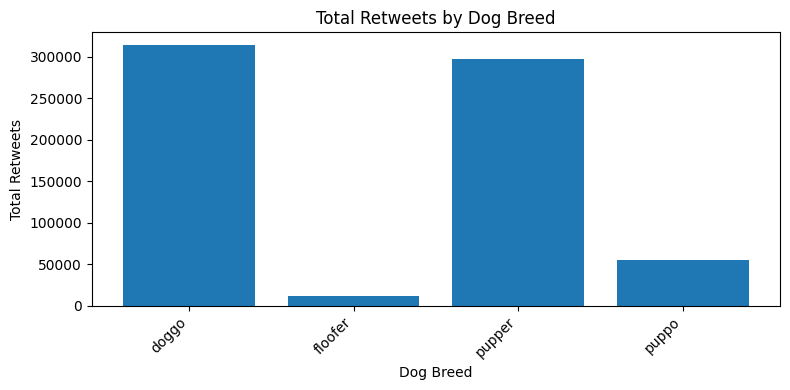

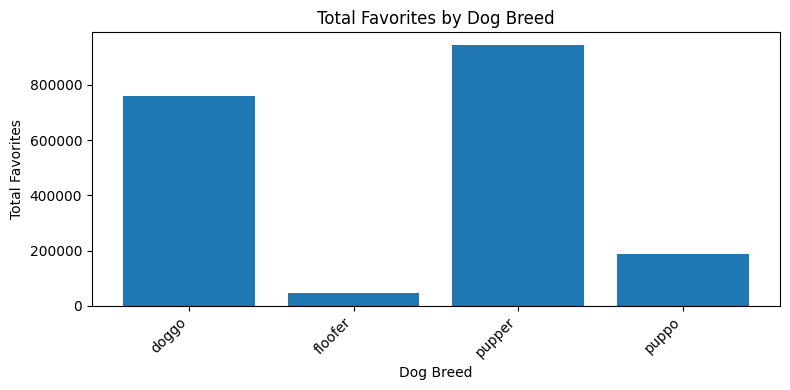

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert the 'rating' column to numeric, handling errors
twitter_archive_master['rating'] = pd.to_numeric(twitter_archive_master['rating'], errors='coerce')

# Group by dog breed and calculate average rating and total retweets/favorites
breed_stats = twitter_archive_master.groupby('dog_breed').agg({'rating': 'mean', 'retweet_count': 'sum', 'favorite_count': 'sum'})

# Sort by average rating in descending order
breed_stats_sorted = breed_stats.sort_values('rating', ascending=False)

# Create a smaller bar chart for total retweets
plt.figure(figsize=(8, 4))  # Adjusted size
plt.bar(breed_stats_sorted.index, breed_stats_sorted['retweet_count'])
plt.xlabel('Dog Breed')
plt.ylabel('Total Retweets')
plt.title('Total Retweets by Dog Breed')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Create a smaller bar chart for total favorites
plt.figure(figsize=(8, 4))  # Adjusted size
plt.bar(breed_stats_sorted.index, breed_stats_sorted['favorite_count'])
plt.xlabel('Dog Breed')
plt.ylabel('Total Favorites')
plt.title('Total Favorites by Dog Breed')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()